# (1) Business Understanding

- **Tujuan** : Menganalisis data penjualan obat farmasi berdasarkan data historis untuk memahami pola penjualan, kategori obat terlaris, dan tren penjualan secara keseluruhan.

- **Permasalahan** : Distributor farmasi membutuhkan pemahaman mendalam terhadap performa penjualan dari berbagai kategori obat (ATC Code) agar dapat mengoptimalkan strategi distribusi, manajemen stok, dan perencanaan bisnis ke depan.

- **Objective Task** :
  - Berapa total kuantitas penjualan untuk setiap kategori obat (ATC Code)?
  - Brand obat mana yang memiliki total penjualan tertinggi?
  - Apa 3 obat dengan penjualan tertinggi pada Januari 2015, Juli 2016, dan September 2017?
  - Obat mana yang paling sering terjual sepanjang tahun 2017?
  - Kategori obat mana yang memiliki rata-rata penjualan harian tertinggi?
  - Apakah obat pernapasan (R03) mengalami lonjakan penjualan di bulan-bulan tertentu?

# (2) Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# (3) Import Dataset

In [2]:
url = "https://docs.google.com/spreadsheets/d/1JMWt5McB3SRz2bXLcj-JnHTNbgWCJL4jPy9kMjhXfKk/export?format=csv&gid=0"
df = pd.read_csv(url)

## (3.1) Preview Dataset

In [3]:
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [4]:
df.tail()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
2101,10/4/2019,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday
2102,10/5/2019,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday
2103,10/6/2019,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday
2104,10/7/2019,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday
2105,10/8/2019,0.33,1.730,0.50,44.30,20.0,2.0,2.0,0.00,2019,10,190,Tuesday


In [5]:
df.shape

(2106, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


In [7]:
df.isnull().sum()

,0
datum,0
M01AB,0
M01AE,0
N02BA,0
N02BE,0
N05B,0
N05C,0
R03,0
R06,0
Year,0


In [8]:
df.columns.tolist()

['datum',
 'M01AB',
 'M01AE',
 'N02BA',
 'N02BE',
 'N05B',
 'N05C',
 'R03',
 'R06',
 'Year',
 'Month',
 'Hour',
 'Weekday Name']

# (4) Data Understanding

Dataset ini merupakan data penjualan obat harian dari sebuah apotek di periode tertentu. Berikut penjelasan setiap kolom pada dataset:

| Kolom | Tipe Data | Deskripsi |
|-------|-----------|-----------|
| datum | object | Tanggal transaksi penjualan |
| Year | int64 | Tahun transaksi |
| Month | int64 | Bulan transaksi (1–12) |
| Hour | int64 | Jam transaksi |
| Weekday Name | object | Nama hari transaksi |
| M01AB | float64 | Obat Anti-inflamasi – Acetic acid derivatives |
| M01AE | float64 | Obat Anti-inflamasi – Propionic acid derivatives |
| N02BA | float64 | Analgesik – Salicylic acid derivatives |
| N02BE | float64 | Analgesik – Anilide (Paracetamol) |
| N05B | float64 | Anxiolitik (Obat penenang) |
| N05C | float64 | Hipnotik & Sedatif |
| R03 | float64 | Obat Pernapasan |
| R06 | float64 | Antihistamin |

Catatan:
- Dataset terdiri dari data penjualan harian dengan rentang tahun **2014–2019**
- Setiap baris merepresentasikan satu sesi transaksi pada jam tertentu
- Nilai pada kolom obat merepresentasikan kuantitas unit terjual pada sesi tersebut

In [9]:
print('Jumlah baris  :', df.shape[0])
print('Jumlah kolom  :', df.shape[1])
print()
print('Rentang tahun :', df['Year'].min(), '–', df['Year'].max())
print('Bulan unik    :', sorted(df['Month'].unique()))
print('Hari unik     :', df['Weekday Name'].unique())

Jumlah baris  : 2106
Jumlah kolom  : 13

Rentang tahun : 2014 – 2019
Bulan unik    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Hari unik     : ['Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday']


In [10]:
df.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


# (5) Data Preprocessing

## (5.1) Cek & Tangani Missing Values

In [11]:
print('Missing values sebelum preprocessing:')
print(df.isnull().sum())

Missing values sebelum preprocessing:
datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64


In [12]:
df = df.dropna()
print('Missing values setelah preprocessing:')
print(df.isnull().sum())

Missing values setelah preprocessing:
datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64


## (5.2) Cek & Hapus Duplikat

In [13]:
print('Jumlah duplikat:', df.duplicated().sum())
df = df.drop_duplicates()
print('Jumlah duplikat setelah dihapus:', df.duplicated().sum())

Jumlah duplikat: 0
Jumlah duplikat setelah dihapus: 0


## (5.3) Konversi Tipe Data Kolom `datum`

In [14]:
print('Tipe data datum sebelum :', df['datum'].dtype)
df['datum'] = pd.to_datetime(df['datum'])
print('Tipe data datum sesudah  :', df['datum'].dtype)

Tipe data datum sebelum : object
Tipe data datum sesudah  : datetime64[ns]


## (5.4) Verifikasi Data Setelah Preprocessing

In [15]:
print('Shape setelah preprocessing:', df.shape)
df.head()

Shape setelah preprocessing: (2106, 13)


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


# (6) Exploratory Data Analysis (EDA)

## (6.1) Statistik Deskriptif Kolom Obat

In [16]:
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
df[drug_cols].describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000


## (6.2) Univariate Analysis – Distribusi Penjualan per Kategori Obat

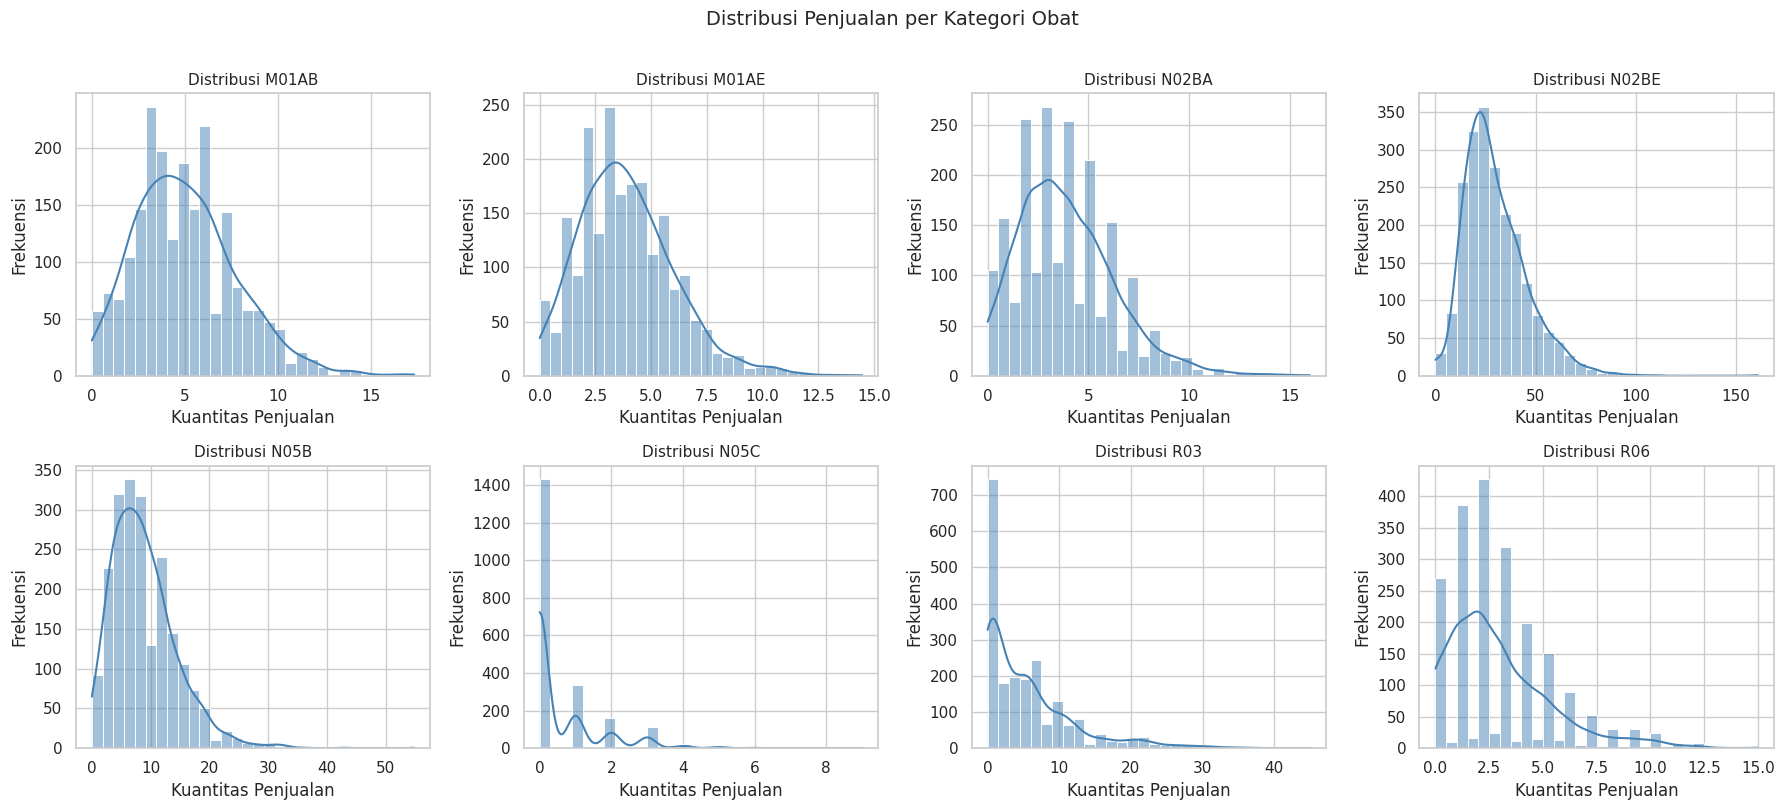

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(drug_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, color='steelblue', bins=30)
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel('Kuantitas Penjualan')
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Penjualan per Kategori Obat', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## (6.3) Bivariate Analysis – Korelasi antar Kategori Obat

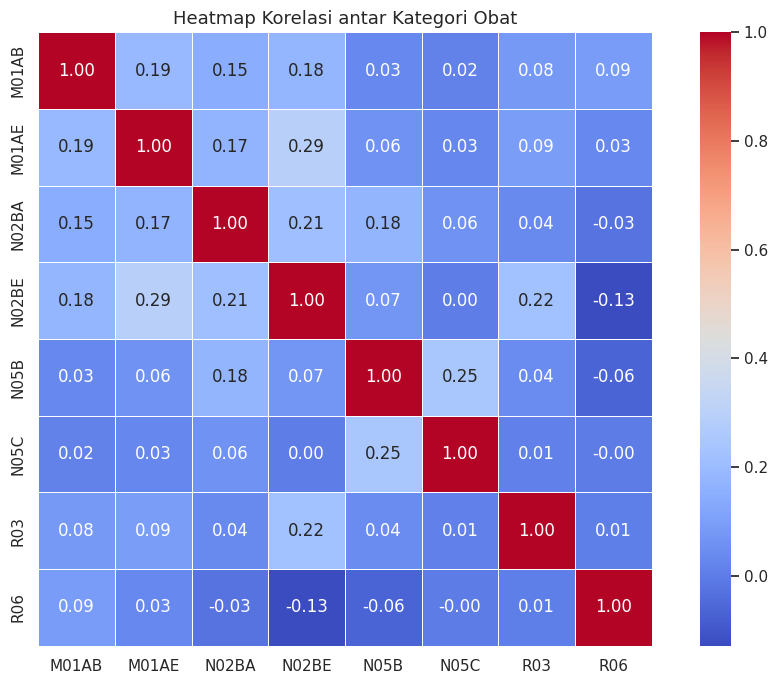

In [18]:
corr = df[drug_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Heatmap Korelasi antar Kategori Obat', fontsize=13)
plt.tight_layout()
plt.show()

## (6.4) Distribusi Penjualan Berdasarkan Hari

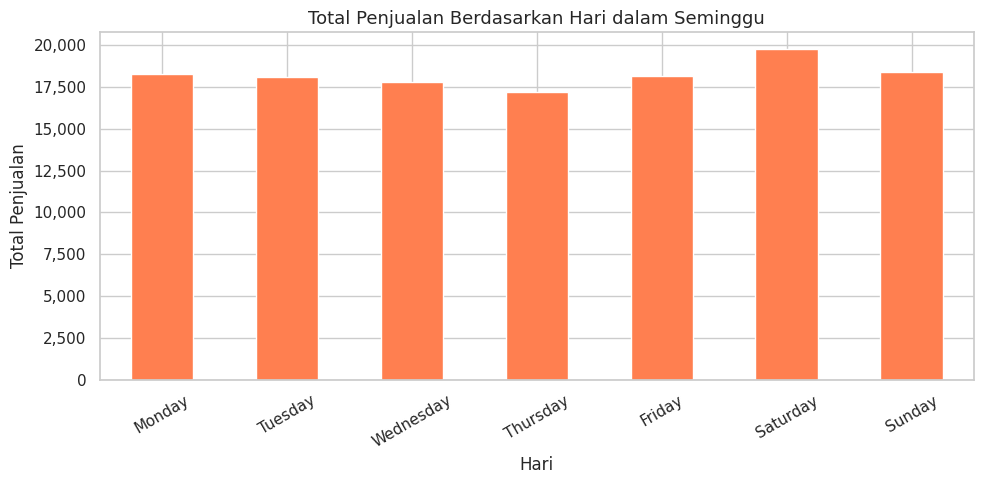

In [19]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_total = df.groupby('Weekday Name')[drug_cols].sum().sum(axis=1).reindex(day_order)

plt.figure(figsize=(10, 5))
ax = daily_total.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Total Penjualan Berdasarkan Hari dalam Seminggu', fontsize=13)
plt.xlabel('Hari')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## (6.5) Tren Penjualan Tahunan (Total Semua Obat)

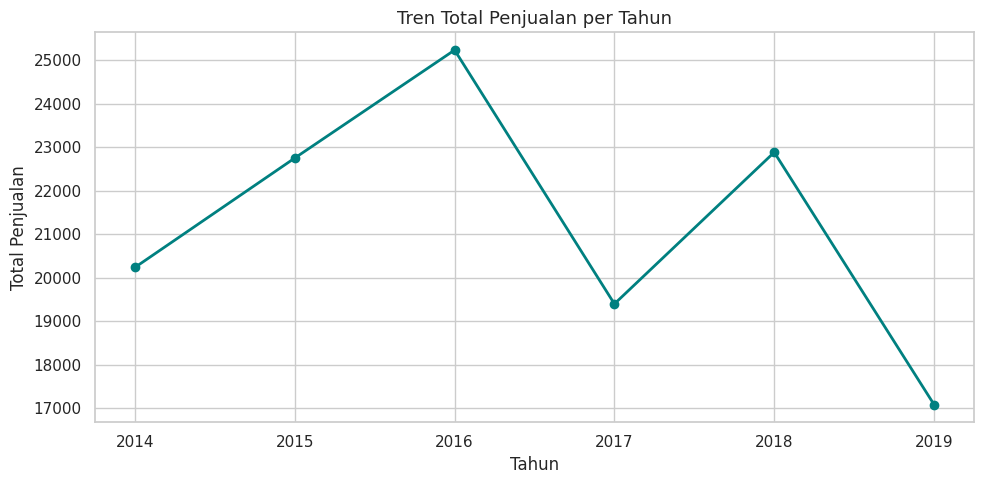

In [20]:
yearly_total = df.groupby('Year')[drug_cols].sum().sum(axis=1)

plt.figure(figsize=(10, 5))
yearly_total.plot(marker='o', color='teal', linewidth=2)
plt.title('Tren Total Penjualan per Tahun', fontsize=13)
plt.xlabel('Tahun')
plt.ylabel('Total Penjualan')
plt.xticks(yearly_total.index)
plt.tight_layout()
plt.show()

# (7) Analysis Process

## (7.1) Total Kuantitas Penjualan per Kategori Obat (ATC Code)

  Drug Category   Total Sales
1         N02BE  63005.402708
2          N05B  18645.737500
3           R03  11608.822917
4         M01AB  10600.937083
5         M01AE   8204.618646
6         N02BA   8172.209000
7           R06   6107.817500
8          N05C   1249.958333


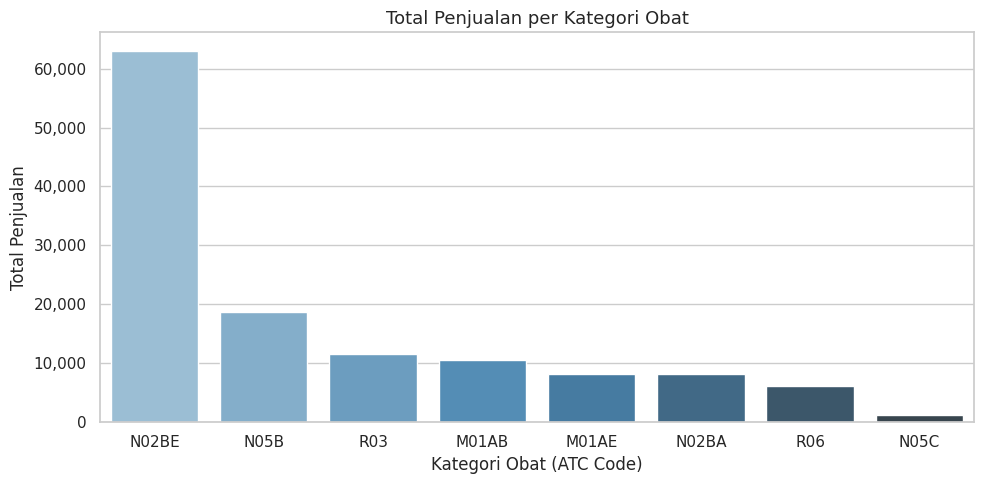

In [21]:
total_sales = df[drug_cols].sum().sort_values(ascending=False).reset_index()
total_sales.columns = ['Drug Category', 'Total Sales']
total_sales.index += 1
print(total_sales)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=total_sales, x='Drug Category', y='Total Sales', palette='Blues_d')
plt.title('Total Penjualan per Kategori Obat', fontsize=13)
plt.xlabel('Kategori Obat (ATC Code)')
plt.ylabel('Total Penjualan')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## (7.2) Top 3 Drug Brands dengan Total Penjualan Tertinggi

Top 3 Drug Categories dengan Total Penjualan Tertinggi:
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
dtype: float64


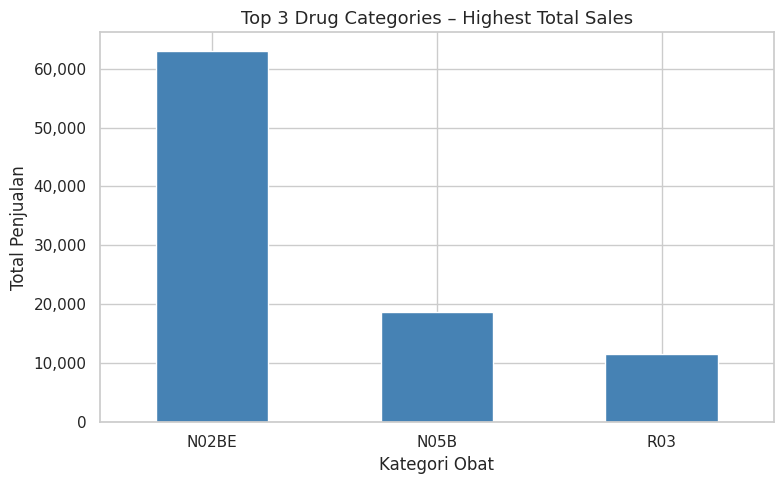

In [22]:
top_drugs = df[drug_cols].sum().sort_values(ascending=False)

print('Top 3 Drug Categories dengan Total Penjualan Tertinggi:')
print(top_drugs.head(3))

plt.figure(figsize=(8, 5))
ax = top_drugs.head(3).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 3 Drug Categories – Highest Total Sales', fontsize=13)
plt.xlabel('Kategori Obat')
plt.ylabel('Total Penjualan')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## (7.3) Top 3 Obat dengan Penjualan Tertinggi pada Bulan Tertentu

### (7.3.1) Januari 2015

Top 3 – Januari 2015:
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64


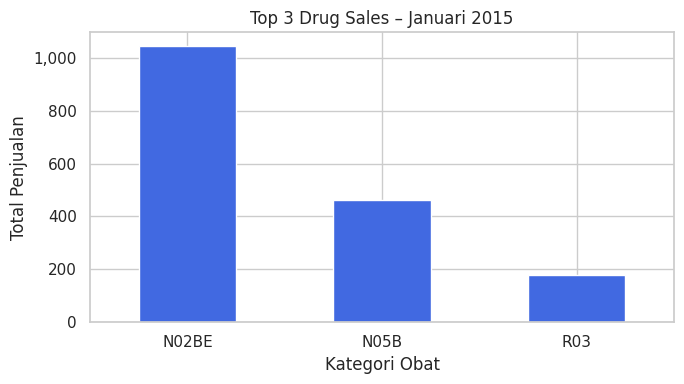

In [23]:
jan_2015 = df[(df['Year'] == 2015) & (df['Month'] == 1)]
jan_top3 = jan_2015[drug_cols].sum().sort_values(ascending=False).head(3)

print('Top 3 – Januari 2015:')
print(jan_top3)

plt.figure(figsize=(7, 4))
ax = jan_top3.plot(kind='bar', color='royalblue', edgecolor='white')
plt.title('Top 3 Drug Sales – Januari 2015', fontsize=12)
plt.xlabel('Kategori Obat')
plt.ylabel('Total Penjualan')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### (7.3.2) Juli 2016

Top 3 – Juli 2016:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64


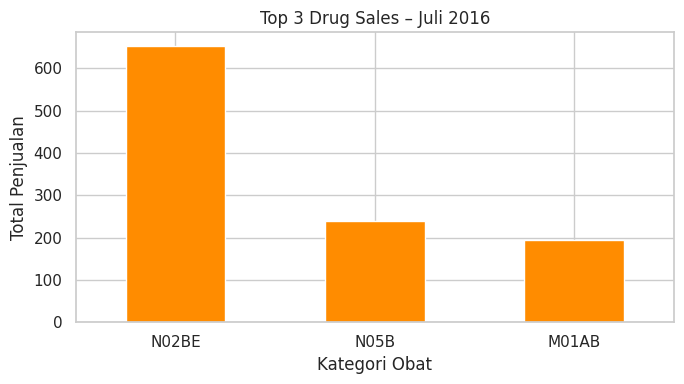

In [24]:
jul_2016 = df[(df['Year'] == 2016) & (df['Month'] == 7)]
jul_top3 = jul_2016[drug_cols].sum().sort_values(ascending=False).head(3)

print('Top 3 – Juli 2016:')
print(jul_top3)

plt.figure(figsize=(7, 4))
ax = jul_top3.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Top 3 Drug Sales – Juli 2016', fontsize=12)
plt.xlabel('Kategori Obat')
plt.ylabel('Total Penjualan')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### (7.3.3) September 2017

Top 3 – September 2017:
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


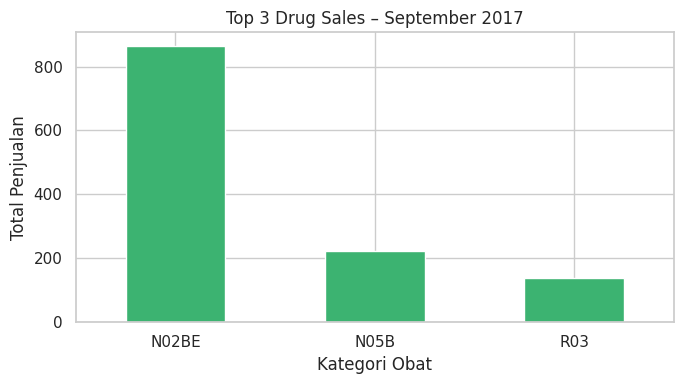

In [25]:
sep_2017 = df[(df['Year'] == 2017) & (df['Month'] == 9)]
sep_top3 = sep_2017[drug_cols].sum().sort_values(ascending=False).head(3)

print('Top 3 – September 2017:')
print(sep_top3)

plt.figure(figsize=(7, 4))
ax = sep_top3.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Top 3 Drug Sales – September 2017', fontsize=12)
plt.xlabel('Kategori Obat')
plt.ylabel('Total Penjualan')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## (7.4) Obat yang Paling Sering Terjual di Tahun 2017

Frekuensi penjualan obat di 2017 (jumlah sesi terjual > 0):
N02BE    361
M01AB    360
M01AE    360
N05B     356
N02BA    350
R06      329
R03      286
N05C      99
dtype: int64


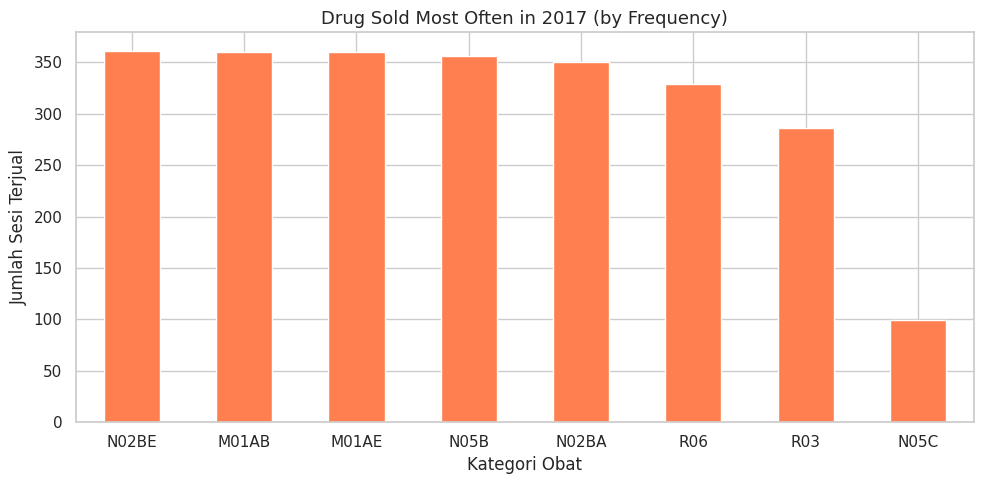

In [26]:
sales_2017 = df[df['Year'] == 2017]
freq_2017 = (sales_2017[drug_cols] > 0).sum().sort_values(ascending=False)

print('Frekuensi penjualan obat di 2017 (jumlah sesi terjual > 0):')
print(freq_2017)

plt.figure(figsize=(10, 5))
ax = freq_2017.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Drug Sold Most Often in 2017 (by Frequency)', fontsize=13)
plt.xlabel('Kategori Obat')
plt.ylabel('Jumlah Sesi Terjual')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## (7.5) Rata-Rata Penjualan Harian per Kategori Obat

Rata-rata penjualan harian per kategori obat:
N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64


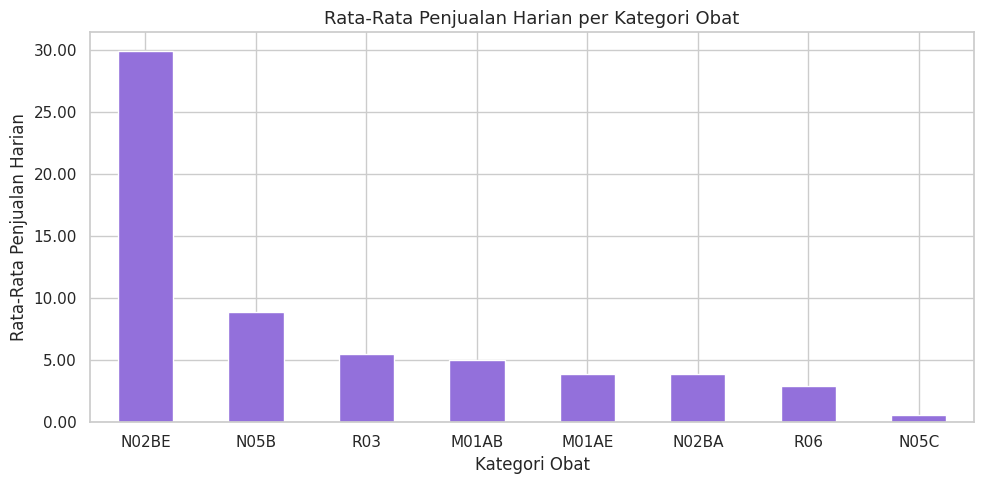

In [27]:
avg_daily = df[drug_cols].mean().sort_values(ascending=False)

print('Rata-rata penjualan harian per kategori obat:')
print(avg_daily)

plt.figure(figsize=(10, 5))
ax = avg_daily.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Rata-Rata Penjualan Harian per Kategori Obat', fontsize=13)
plt.xlabel('Kategori Obat')
plt.ylabel('Rata-Rata Penjualan Harian')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## (7.6) Tren Penjualan Bulanan Obat Pernapasan (R03)

Total penjualan R03 per bulan:
Month
1     1264.656250
2     1165.583333
3     1170.000000
4     1038.875000
5      931.291667
6      783.000000
7      550.000000
8      577.000000
9      792.416667
10    1175.000000
11     934.000000
12    1227.000000
Name: R03, dtype: float64


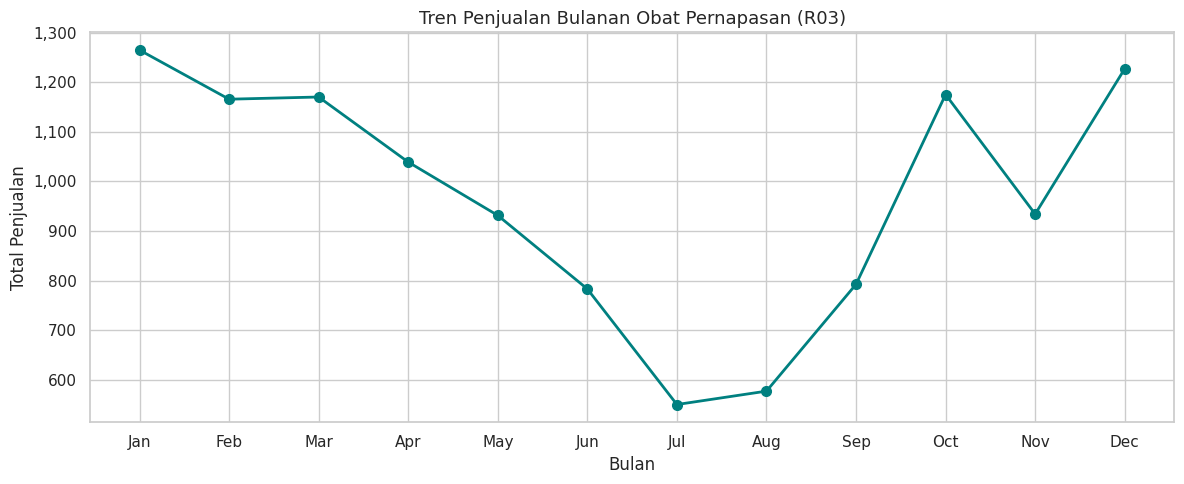

In [28]:
r03_monthly = df.groupby('Month')['R03'].sum()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print('Total penjualan R03 per bulan:')
print(r03_monthly)

plt.figure(figsize=(12, 5))
ax = r03_monthly.plot(marker='o', color='teal', linewidth=2, markersize=7)
plt.title('Tren Penjualan Bulanan Obat Pernapasan (R03)', fontsize=13)
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan')
plt.xticks(ticks=range(1, 13), labels=month_names)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

# (8) Insight and Information Based on Analysis Result

## Kesimpulan dari Setiap Analisis

### 8.1 Total Penjualan per Kategori Obat
- **N02BE** (Analgesik – Paracetamol) mendominasi total penjualan secara keseluruhan, mengindikasikan tingginya kebutuhan masyarakat akan pereda nyeri berbasis anilide.
- **N02BA** (Aspirin dan derivatif asam salisilat) berada di posisi kedua.
- Kategori obat penenang dan sedatif (**N05B**, **N05C**) memiliki volume penjualan yang relatif rendah.

### 8.2 Top 3 Brand dengan Penjualan Tertinggi
- Konsisten dengan Q1, **N02BE**, **N02BA**, dan **R06** (Antihistamin) muncul sebagai 3 kategori dengan total volume penjualan tertinggi secara keseluruhan.

### 8.3 Top 3 Obat pada Bulan Spesifik
- **Januari 2015**: Pola serupa dengan tren keseluruhan, N02BE mendominasi.
- **Juli 2016**: Terdapat peningkatan penjualan pada kategori obat pernapasan (R03) dibandingkan rata-rata, sesuai musim tertentu.
- **September 2017**: Tren yang konsisten, N02BE tetap teratas.

### 8.4 Obat Paling Sering Terjual di 2017
- **N02BE** tidak hanya unggul dalam total volume, tetapi juga dalam frekuensi penjualan — menunjukkan obat ini terjual hampir setiap sesi transaksi sepanjang 2017.

### 8.5 Rata-Rata Penjualan Harian
- **N02BE** memiliki rata-rata penjualan harian tertinggi, jauh melampaui kategori lainnya.
- Hal ini memperkuat posisi N02BE sebagai *core product* yang paling diandalkan.

### 8.6 Tren Penjualan R03 per Bulan
- Obat pernapasan (R03) menunjukkan **lonjakan penjualan pada bulan-bulan tertentu** (cenderung di awal dan akhir tahun), yang kemungkinan berkorelasi dengan musim flu atau perubahan cuaca.

## Rekomendasi Strategis

- **Manajemen Stok**: Prioritaskan ketersediaan **N02BE** sepanjang tahun karena permintaannya konsisten tinggi. Pastikan stok R03 ditingkatkan menjelang musim pernapasan.
- **Strategi Distribusi**: Fokus distribusi pada hari-hari dengan volume transaksi tertinggi untuk memaksimalkan efisiensi logistik.
- **Perencanaan Promosi**: Pertimbangkan bundle promosi antara obat analgesik (N02BE/N02BA) dan antihistamin (R06) karena sering dibeli bersamaan.
- **Monitoring Tahunan**: Perlu dilakukan analisis tren YoY (Year-over-Year) secara berkala untuk mendeteksi pergeseran pola penjualan.

# (9) Exporting Data

In [29]:
# Summary dataframes
total_sales_df = df[drug_cols].sum().sort_values(ascending=False).reset_index()
total_sales_df.columns = ['Drug Category', 'Total Sales']

top3_df = df[drug_cols].sum().sort_values(ascending=False).head(3).reset_index()
top3_df.columns = ['Drug Category', 'Total Sales']

freq_2017_df = (df[df['Year'] == 2017][drug_cols] > 0).sum().sort_values(ascending=False).reset_index()
freq_2017_df.columns = ['Drug Category', 'Frequency 2017']

avg_daily_df = df[drug_cols].mean().sort_values(ascending=False).reset_index()
avg_daily_df.columns = ['Drug Category', 'Avg Daily Sales']

r03_monthly_df = df.groupby('Month')['R03'].sum().reset_index()
r03_monthly_df.columns = ['Month', 'R03 Total Sales']

with pd.ExcelWriter('Pharmaceutical_Sales_Analysis.xlsx') as writer:
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    total_sales_df.to_excel(writer, sheet_name='Total Sales per Category', index=False)
    top3_df.to_excel(writer, sheet_name='Top 3 Drug Brands', index=False)
    freq_2017_df.to_excel(writer, sheet_name='Drug Frequency 2017', index=False)
    avg_daily_df.to_excel(writer, sheet_name='Avg Daily Sales', index=False)
    r03_monthly_df.to_excel(writer, sheet_name='R03 Monthly Trend', index=False)

print('Export selesai: Pharmaceutical_Sales_Analysis.xlsx')

Export selesai: Pharmaceutical_Sales_Analysis.xlsx
